# LİNEER MODELLERİN TESTİ

In [18]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import skew, kurtosis
import os
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 16
sns.set_palette("husl")

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

try:
    from pygam import LinearGAM, s, l
    GAM_AVAILABLE = True
except ImportError:
    GAM_AVAILABLE = False

import mlflow
import mlflow.sklearn

import yaml
import shutil

MLFLOW_EXPERIMENT_NAME = "01_Linear_Models_Benchmarking"
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

import warnings
warnings.filterwarnings('ignore')


In [6]:
df = pd.read_csv("C:/Users/Asus/montesinho-fire-risk-prediction/data/raw/forestfires.csv")

print("Veri Boyutu:", df.shape)
df.describe()

df.head(10)

Veri Boyutu: (517, 13)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


In [7]:
y_raw = df['area'].values
y_log = np.log1p(df['area'].values) 

def evaluate_and_log_model(model, X_test, y_test_log, y_test_raw, 
                           model_name, setup_name, feature_names, 
                           scaler_name="StandardScaler", extra_params=None):
    y_pred_log = model.predict(X_test)
    
    log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
    log_mae = mean_absolute_error(y_test_log, y_pred_log)
    r2 = r2_score(y_test_log, y_pred_log)
    
    y_pred_raw = np.expm1(y_pred_log)
    y_pred_raw = np.clip(y_pred_raw, a_min=0.0, a_max=None)
    
    ha_rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
    ha_mad = mean_absolute_error(y_test_raw, y_pred_raw) 
    
    zero_mask = (y_test_raw == 0.0)
    zero_day_fp_sum = np.sum(y_pred_raw[zero_mask])
    zero_day_fp_mean = np.mean(y_pred_raw[zero_mask])
    
    with mlflow.start_run(run_name=f"{model_name}_{setup_name}") as run:
        mlflow.log_param("model_family", "Linear_Models")
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("feature_setup", setup_name)
        mlflow.log_param("num_features", len(feature_names))
        mlflow.log_param("features_list", str(feature_names))
        mlflow.log_param("scaler", scaler_name)
        if extra_params:
            for k, v in extra_params.items():
                mlflow.log_param(k, v)
        
        mlflow.log_metric("val_log_rmse", log_rmse)
        mlflow.log_metric("val_log_mae", log_mae)
        mlflow.log_metric("val_r2", r2)
        mlflow.log_metric("test_ha_rmse", ha_rmse)
        mlflow.log_metric("test_ha_mad", ha_mad)  
        mlflow.log_metric("zero_day_fp_sum_ha", zero_day_fp_sum)
        mlflow.log_metric("zero_day_fp_mean_ha", zero_day_fp_mean)
        
        try:
            mlflow.sklearn.log_model(model, "model")
        except Exception as e:
            pass
            
    results = {
        "Model": model_name,
        "Setup": setup_name,
        "Num_Features": len(feature_names),
        "R2_Score": r2,
        "Log_RMSE": log_rmse,
        "Hectare_RMSE_ha": ha_rmse,
        "Cortez_MAD_ha": ha_mad,
        "Zero_Day_FP_Sum_ha": zero_day_fp_sum
    }
    
    return results


### Kodun açıklaması
Kuracağımız doğrusal modellerin normal dağılım varsayımını sağlayabilmesi için, aşırı sağa çarpık (`+12.85`) olan hedef değişkenimizi **`np.log1p` ($y = \ln(\text{area} + 1)$)** dönüşümü uyguladık. Ayrıca tahminleri gerçek hektara ($e^{\hat{y}} - 1$) çevirecek bir sistem kurup , Cortez (2007)'nin orijinal **`MAD = 12.71 ha`** hatasıyla adilce kıyaslıyor ve her denememizi tek satır ek kod yazmadan otomatik olarak **MLflow** veritabanına kaydediyoruz.

In [8]:
X = df.drop(columns=['area'])

X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y_raw, test_size=0.20, random_state=42
)

num_cols = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
cat_cols = ['month', 'day']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f" Eğitim Seti (X_train_scaled) Boyutu : {X_train_scaled.shape[0]} satır, {X_train_scaled.shape[1]} sütun")
print(f" Test Seti   (X_test_scaled)  Boyutu : {X_test_scaled.shape[0]} satır, {X_test_scaled.shape[1]} sütun")
print("-" * 80)
print(" X_train ölçeklendirilmiş ortalama (ilk 3 sütun):")
print(X_train_scaled[num_cols[:3]].mean().round(4).to_dict())
print(" X_train ölçeklendirilmiş standart sapma:")
print(X_train_scaled[num_cols[:3]].std().round(4).to_dict())

 Eğitim Seti (X_train_scaled) Boyutu : 413 satır, 12 sütun
 Test Seti   (X_test_scaled)  Boyutu : 104 satır, 12 sütun
--------------------------------------------------------------------------------
 X_train ölçeklendirilmiş ortalama (ilk 3 sütun):
{'X': 0.0, 'Y': -0.0, 'FFMC': -0.0}
 X_train ölçeklendirilmiş standart sapma:
{'X': 1.0012, 'Y': 1.0012, 'FFMC': 1.0012}


In [9]:
X_train_encoded = pd.get_dummies(X_train_scaled, columns=['month', 'day'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test_scaled, columns=['month', 'day'], drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

all_features_list = list(X_train_encoded.columns)

print(all_features_list[:10], "...\n")

['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain'] ...



## DENEME 1 -  HAM VERİNİN 5 DOĞRUSAL MODEL TESTİ

In [17]:
m_cols = list(X_train_encoded.columns)
X_train_M = X_train_encoded.copy()
X_test_M = X_test_encoded.copy()

deneme1_results = []

# 1. OLS (Linear Regression) 
ols_model = LinearRegression().fit(X_train_M, y_train_log)
deneme1_results.append(evaluate_and_log_model(ols_model, X_test_M, y_test_log, y_test_raw, 
                                            "OLS_LinearRegression", "Deneme1_All_Cols", m_cols))

# 2. Ridge Regression
ridge_alphas = np.logspace(-4, 3, 100)
ridge_model = RidgeCV(alphas=ridge_alphas, cv=5, scoring='neg_mean_squared_error').fit(X_train_M, y_train_log)
deneme1_results.append(evaluate_and_log_model(ridge_model, X_test_M, y_test_log, y_test_raw, 
                                            "Ridge_Regression", "Deneme1_All_Cols", m_cols, 
                                            extra_params={"best_alpha": ridge_model.alpha_}))

# 3. Lasso Regressionye
lasso_model = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=5000, n_jobs=-1, random_state=42).fit(X_train_M, y_train_log)
deneme1_results.append(evaluate_and_log_model(lasso_model, X_test_M, y_test_log, y_test_raw, 
                                            "Lasso_Regression", "Deneme1_All_Cols", m_cols, 
                                            extra_params={"best_alpha": lasso_model.alpha_}))

# 4. ElasticNet
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
enet_model = ElasticNetCV(l1_ratio=l1_ratios, alphas=np.logspace(-4, 1, 50), cv=5, max_iter=5000, n_jobs=-1, random_state=42).fit(X_train_M, y_train_log)
deneme1_results.append(evaluate_and_log_model(enet_model, X_test_M, y_test_log, y_test_raw, 
                                            "ElasticNet_Regression", "Deneme1_All_Cols", m_cols, 
                                            extra_params={"best_alpha": enet_model.alpha_, "best_l1_ratio": enet_model.l1_ratio_}))

# 5. GAMs 
if GAM_AVAILABLE:
    try:
        terms = [l(i) if (c.startswith('month_') or c.startswith('day_')) else s(i, n_splines=6) for i, c in enumerate(m_cols)]
        gam_formula = terms[0]
        for t in terms[1:]: gam_formula += t
        gam_model = LinearGAM(gam_formula).gridsearch(X_train_M.values, y_train_log, lam=np.logspace(-2, 2, 5))
        
        class GAMWrapper:
            def __init__(self, obj): self.obj = obj
            def predict(self, X): return self.obj.predict(X.values if hasattr(X, 'values') else X)
            
        deneme1_results.append(evaluate_and_log_model(GAMWrapper(gam_model), X_test_M, y_test_log, y_test_raw, 
                                                    "GAMs_LinearGAM", "Deneme1_All_Cols", m_cols))
    except Exception: pass

df_deneme1 = pd.DataFrame(deneme1_results).sort_values(by="Cortez_MAD_ha", ascending=True).reset_index(drop=True)

display(df_deneme1[["Model", "Setup", "R2_Score", "Log_RMSE", "Hectare_RMSE_ha", "Cortez_MAD_ha", "Zero_Day_FP_Sum_ha"]].round(4))


2026/07/10 01:40:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 01:40:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 01:41:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 01:41:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
  0% (0 of 5) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 20% (1 of 5) |#####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 40% (2 of 5) |##########                | Elapsed Time: 0:00:00 ETA:   0:00:01
 60% (3 of 5) |###############           | Elapsed Time: 0:00:01 ETA:   0:00:00
 80% (4 of 5) |####################      | Elapsed Time: 0:00:01 ETA:   0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:01 Time:  0:00:01
2026/07/10 01:41:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `

,Model,Setup,R2_Score,Log_RMSE,Hectare_RMSE_ha,Cortez_MAD_ha,Zero_Day_FP_Sum_ha
0,GAMs_LinearGAM,Deneme1_All_Cols,0.0106,1.4746,109.8851,19.7980,99.6897
1,Ridge_Regression,Deneme1_All_Cols,0.0058,1.4782,109.9705,19.8073,101.1558
2,Lasso_Regression,Deneme1_All_Cols,-0.0006,1.4830,109.9957,19.8188,102.7652
3,ElasticNet_Regression,Deneme1_All_Cols,-0.0017,1.4838,109.9950,19.8192,102.4571
4,OLS_LinearRegression,Deneme1_All_Cols,-0.0472,1.5171,109.7993,20.1068,145.8549


### Deneme 1 Değerlendirme Raporu

Tüm 12 değişkenin modellere verildiği bu ilk denemedeki sonuçlar:

1. **OLS:** Birbirine bağımlı kuraklık (`FFMC, DMC, DC`) ve hava (`temp, RH, wind`) değişkenlerinin yarattığı **Çoklu Doğrusallık (`Multicollinearity`)**, OLS modelinde katsayı sistemini çökertti. Model **`-0.0472` negatif $R^2$** üretmiş ve, gerçekte hiç yangın çıkmayan sıfır günlerinde toplam **`145.85 hektar` `False Positive` durumu yaşanmış.**
2. **Ridge ve GAMs:** `Ridge` regresyonu, $L_2$ ceza katsayısı ($\alpha$) sayesinde katsayıları düzenleyerek sahte pozitif durumunu **`101.15 hektara`** düşürmüş ve varyansı stabilize etmiştir. Doğrusal olmayan ilişkileri 6 bükümlü eğrilerle (`Splines`) modelleyen **`GAMs (LinearGAM)`**, **`MAD = 19.798 ha`** ve **`99.68 ha`** sahte alarm skoruyla Deneme 1'in en iyi modelidir
3. **Mekan ve Takvim Gürültüsü:** Modellerin `19.79 ha` bandında sıkışması, 14 adet One-Hot takvim sütununun (`month, day`) ve konum koordinatlarının (`X, Y`) doğrusal denklemlerde aşırı seyreklik ve gürültü yarattığını göstermektedir. Bir sonraki aşamada (**Deneme 2**), bu gürültüler temizlenerek sadece saf meteoroloji verisi test edilecektir.

## DENEME 2: Mekan ve Takvim Gürültüsünün Temizlenmesi

In [10]:
weather_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']

X_train_W = X_train_scaled[weather_cols].copy()
X_test_W = X_test_scaled[weather_cols].copy()

deneme2_results = []

ols_model_W = LinearRegression().fit(X_train_W, y_train_log)
deneme2_results.append(evaluate_and_log_model(ols_model_W, X_test_W, y_test_log, y_test_raw, 
                                            "OLS_LinearRegression", "Deneme2_Pure_Weather", weather_cols))

ridge_model_W = RidgeCV(alphas=np.logspace(-4, 3, 100), cv=5, scoring='neg_mean_squared_error').fit(X_train_W, y_train_log)
deneme2_results.append(evaluate_and_log_model(ridge_model_W, X_test_W, y_test_log, y_test_raw, 
                                            "Ridge_Regression", "Deneme2_Pure_Weather", weather_cols, 
                                            extra_params={"best_alpha": ridge_model_W.alpha_}))

lasso_model_W = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=5000, n_jobs=-1, random_state=42).fit(X_train_W, y_train_log)
deneme2_results.append(evaluate_and_log_model(lasso_model_W, X_test_W, y_test_log, y_test_raw, 
                                            "Lasso_Regression", "Deneme2_Pure_Weather", weather_cols, 
                                            extra_params={"best_alpha": lasso_model_W.alpha_}))

enet_model_W = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], alphas=np.logspace(-4, 1, 50), cv=5, max_iter=5000, n_jobs=-1, random_state=42).fit(X_train_W, y_train_log)
deneme2_results.append(evaluate_and_log_model(enet_model_W, X_test_W, y_test_log, y_test_raw, 
                                            "ElasticNet_Regression", "Deneme2_Pure_Weather", weather_cols, 
                                            extra_params={"best_alpha": enet_model_W.alpha_, "best_l1_ratio": enet_model_W.l1_ratio_}))

if GAM_AVAILABLE:
    try:
        terms_W = [s(i, n_splines=6) for i in range(len(weather_cols))]
        gam_formula_W = terms_W[0]
        for t in terms_W[1:]: gam_formula_W += t
            
        gam_model_W = LinearGAM(gam_formula_W).gridsearch(X_train_W.values, y_train_log, lam=np.logspace(-2, 2, 5))
        
        class GAMWrapper:
            def __init__(self, obj): self.obj = obj
            def predict(self, X): return self.obj.predict(X.values if hasattr(X, 'values') else X)
            
        deneme2_results.append(evaluate_and_log_model(GAMWrapper(gam_model_W), X_test_W, y_test_log, y_test_raw, 
                                                    "GAMs_LinearGAM", "Deneme2_Pure_Weather", weather_cols))
    except Exception as e: pass

df_deneme2 = pd.DataFrame(deneme2_results).sort_values(by="Cortez_MAD_ha", ascending=True).reset_index(drop=True)
display(df_deneme2[["Model", "Setup", "R2_Score", "Log_RMSE", "Hectare_RMSE_ha", "Cortez_MAD_ha", "Zero_Day_FP_Sum_ha"]].round(4))

2026/07/10 10:18:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 10:19:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 10:19:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 10:19:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
  0% (0 of 5) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 40% (2 of 5) |##########                | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
2026/07/10 10:19:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


,Model,Setup,R2_Score,Log_RMSE,Hectare_RMSE_ha,Cortez_MAD_ha,Zero_Day_FP_Sum_ha
0,GAMs_LinearGAM,Deneme2_Pure_Weather,0.0057,1.4783,109.9576,19.7955,100.2078
1,OLS_LinearRegression,Deneme2_Pure_Weather,0.0031,1.4802,109.9597,19.8038,100.4280
2,Ridge_Regression,Deneme2_Pure_Weather,0.0050,1.4788,109.9833,19.8065,101.4946
3,ElasticNet_Regression,Deneme2_Pure_Weather,-0.0029,1.4847,109.9952,19.8188,102.2536
4,Lasso_Regression,Deneme2_Pure_Weather,-0.0037,1.4853,109.9950,19.8189,102.1269


### Deneme 2: Değerlendirme Raporu:

Doğrusal regresyon denklemlerimizde seyreklik (`Sparsity`) ve zamansal gürültü yaratan 14 adet takvim dummysi (`month, day`) ile konum koordinatları (`X, Y`) tamamen çıkarılmıştır. Modellerimiz yalnızca yangının fiziksel davranışını doğrudan belirleyen **8 Sürekli Meteoroloji ve Kuraklık Endeksi (`temp, RH, wind, rain, FFMC, DMC, DC, ISI`)** üzerinde eğitilmiştir. Amacımız, gürültülerden arınmış saf bir fiziksel ortamda doğrusal ve spline modellerin tahmin gücünün nasıl iyileştiğini gözlemlemektir.

## DENEME 3 - CORTEZ MAKALE (ST, FWI, STFWI) EĞİTİMİ

In [12]:
FEATURE_SETUPS = {
    "M_Setup": list(X_train_encoded.columns), 
    "ST_Setup": [c for c in X_train_encoded.columns if c.startswith('month_') or c.startswith('day_') or c in ['X', 'Y']], # 16 Sütun
    "FWI_Setup": ['FFMC', 'DMC', 'DC', 'ISI'],
    "STFWI_Setup": [c for c in X_train_encoded.columns if c.startswith('month_') or c.startswith('day_') or c in ['X', 'Y', 'temp', 'RH', 'wind', 'rain']] # 22 Sütun
}
deneme3_results = []

cortez_setups_to_test = ["ST_Setup", "FWI_Setup", "STFWI_Setup"]

for setup_name in cortez_setups_to_test:
    cols = FEATURE_SETUPS[setup_name]
    X_tr = X_train_encoded[cols].copy()
    X_te = X_test_encoded[cols].copy()
    
    ols_m = LinearRegression().fit(X_tr, y_train_log)
    deneme3_results.append(evaluate_and_log_model(ols_m, X_te, y_test_log, y_test_raw, "OLS_LinearRegression", setup_name, cols))
    
    ridge_m = RidgeCV(alphas=np.logspace(-4, 3, 100), cv=5, scoring='neg_mean_squared_error').fit(X_tr, y_train_log)
    deneme3_results.append(evaluate_and_log_model(ridge_m, X_te, y_test_log, y_test_raw, "Ridge_Regression", setup_name, cols, {"best_alpha": ridge_m.alpha_}))
    
    lasso_m = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=5000, n_jobs=-1, random_state=42).fit(X_tr, y_train_log)
    deneme3_results.append(evaluate_and_log_model(lasso_m, X_te, y_test_log, y_test_raw, "Lasso_Regression", setup_name, cols, {"best_alpha": lasso_m.alpha_}))
    
    enet_m = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], alphas=np.logspace(-4, 1, 50), cv=5, max_iter=5000, n_jobs=-1, random_state=42).fit(X_tr, y_train_log)
    deneme3_results.append(evaluate_and_log_model(enet_m, X_te, y_test_log, y_test_raw, "ElasticNet_Regression", setup_name, cols, {"best_alpha": enet_m.alpha_, "best_l1_ratio": enet_m.l1_ratio_}))
    
    if GAM_AVAILABLE:
        try:
            terms = [l(i) if (c.startswith('month_') or c.startswith('day_')) else s(i, n_splines=6) for i, c in enumerate(cols)]
            gam_f = terms[0]
            for t in terms[1:]: gam_f += t
            gam_m = LinearGAM(gam_f).gridsearch(X_tr.values, y_train_log, lam=np.logspace(-2, 2, 5))
            
            class GAMWrapper:
                def __init__(self, obj): self.obj = obj
                def predict(self, X): return self.obj.predict(X.values if hasattr(X, 'values') else X)
                
            deneme3_results.append(evaluate_and_log_model(GAMWrapper(gam_m), X_te, y_test_log, y_test_raw, "GAMs_LinearGAM", setup_name, cols))
        except Exception: pass

df_deneme3 = pd.DataFrame(deneme3_results).sort_values(by="Cortez_MAD_ha", ascending=True).reset_index(drop=True)

display(df_deneme3[["Model", "Setup", "R2_Score", "Log_RMSE", "Hectare_RMSE_ha", "Cortez_MAD_ha", "Zero_Day_FP_Sum_ha"]].round(4))

2026/07/10 10:31:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 10:31:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 10:31:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 10:31:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
  0% (0 of 5) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 80% (4 of 5) |####################      | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
2026/07/10 10:31:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 10:31:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 10:32:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 

,Model,Setup,R2_Score,Log_RMSE,Hectare_RMSE_ha,Cortez_MAD_ha,Zero_Day_FP_Sum_ha
0,GAMs_LinearGAM,STFWI_Setup,0.0303,1.4599,109.8878,19.7792,101.7296
1,Ridge_Regression,STFWI_Setup,0.0075,1.4770,109.9741,19.8068,102.0452
2,Ridge_Regression,FWI_Setup,-0.0034,1.4850,109.9865,19.8170,101.2575
3,ElasticNet_Regression,ST_Setup,-0.0006,1.4830,109.9957,19.8188,102.7652
4,ElasticNet_Regression,STFWI_Setup,-0.0006,1.4830,109.9957,19.8188,102.7652
5,Lasso_Regression,STFWI_Setup,-0.0006,1.4830,109.9957,19.8188,102.7652
6,Lasso_Regression,ST_Setup,-0.0006,1.4830,109.9957,19.8188,102.7652
7,Lasso_Regression,FWI_Setup,-0.0046,1.4859,109.9949,19.8191,102.0258
8,ElasticNet_Regression,FWI_Setup,-0.0039,1.4854,109.9946,19.8200,102.2032
9,Ridge_Regression,ST_Setup,-0.0000,1.4825,109.9840,19.8222,102.4274


### Deneme 3:Cortez (2007) Makale Sistemlerinin Test Edilmesi
Bu denemede, literatürün referans aldığı **`ST_Setup` (Sadece Mekan+Takvim - 16 Sütun)**, **`FWI_Setup` (Sadece Kanada Kuraklık Endeksleri - 4 Sütun)** ve şampiyon **`STFWI_Setup` (Mekan+Takvim+Hava - 22 Sütun)** kurulumları üzerinde 5 doğrusal ve esnek modelimiz optimize edilmiştir. Tüm denemeler MLflow'a tescil edilmiş olup, makale kurulumlarının başarısı bir sonraki hücrede tüm veritabanı sorgulanarak görselleştirilecektir.

,Model,Setup,R2_Score,Log_RMSE,Hectare_RMSE_ha,Cortez_MAD_ha,Zero_Day_FP_Sum_ha
0,GAMs_LinearGAM,STFWI_Setup,0.0303,1.4599,109.89 ha,19.7792 ha,101.73 ha
1,GAMs_LinearGAM,Deneme2_Pure_Weather,0.0057,1.4783,109.96 ha,19.7955 ha,100.21 ha
2,GAMs_LinearGAM,Deneme1_All_Cols,0.0106,1.4746,109.89 ha,19.7980 ha,99.69 ha
3,OLS_LinearRegression,Deneme2_Pure_Weather,0.0031,1.4802,109.96 ha,19.8038 ha,100.43 ha
4,Ridge_Regression,Deneme2_Pure_Weather,0.0050,1.4788,109.98 ha,19.8065 ha,101.49 ha
5,Ridge_Regression,STFWI_Setup,0.0075,1.4770,109.97 ha,19.8068 ha,102.05 ha
6,Ridge_Regression,Deneme1_All_Cols,0.0058,1.4782,109.97 ha,19.8073 ha,101.16 ha
7,Ridge_Regression,FWI_Setup,-0.0034,1.4850,109.99 ha,19.8170 ha,101.26 ha
8,ElasticNet_Regression,ST_Setup,-0.0006,1.4830,110.00 ha,19.8188 ha,102.77 ha
9,Lasso_Regression,ST_Setup,-0.0006,1.4830,110.00 ha,19.8188 ha,102.77 ha


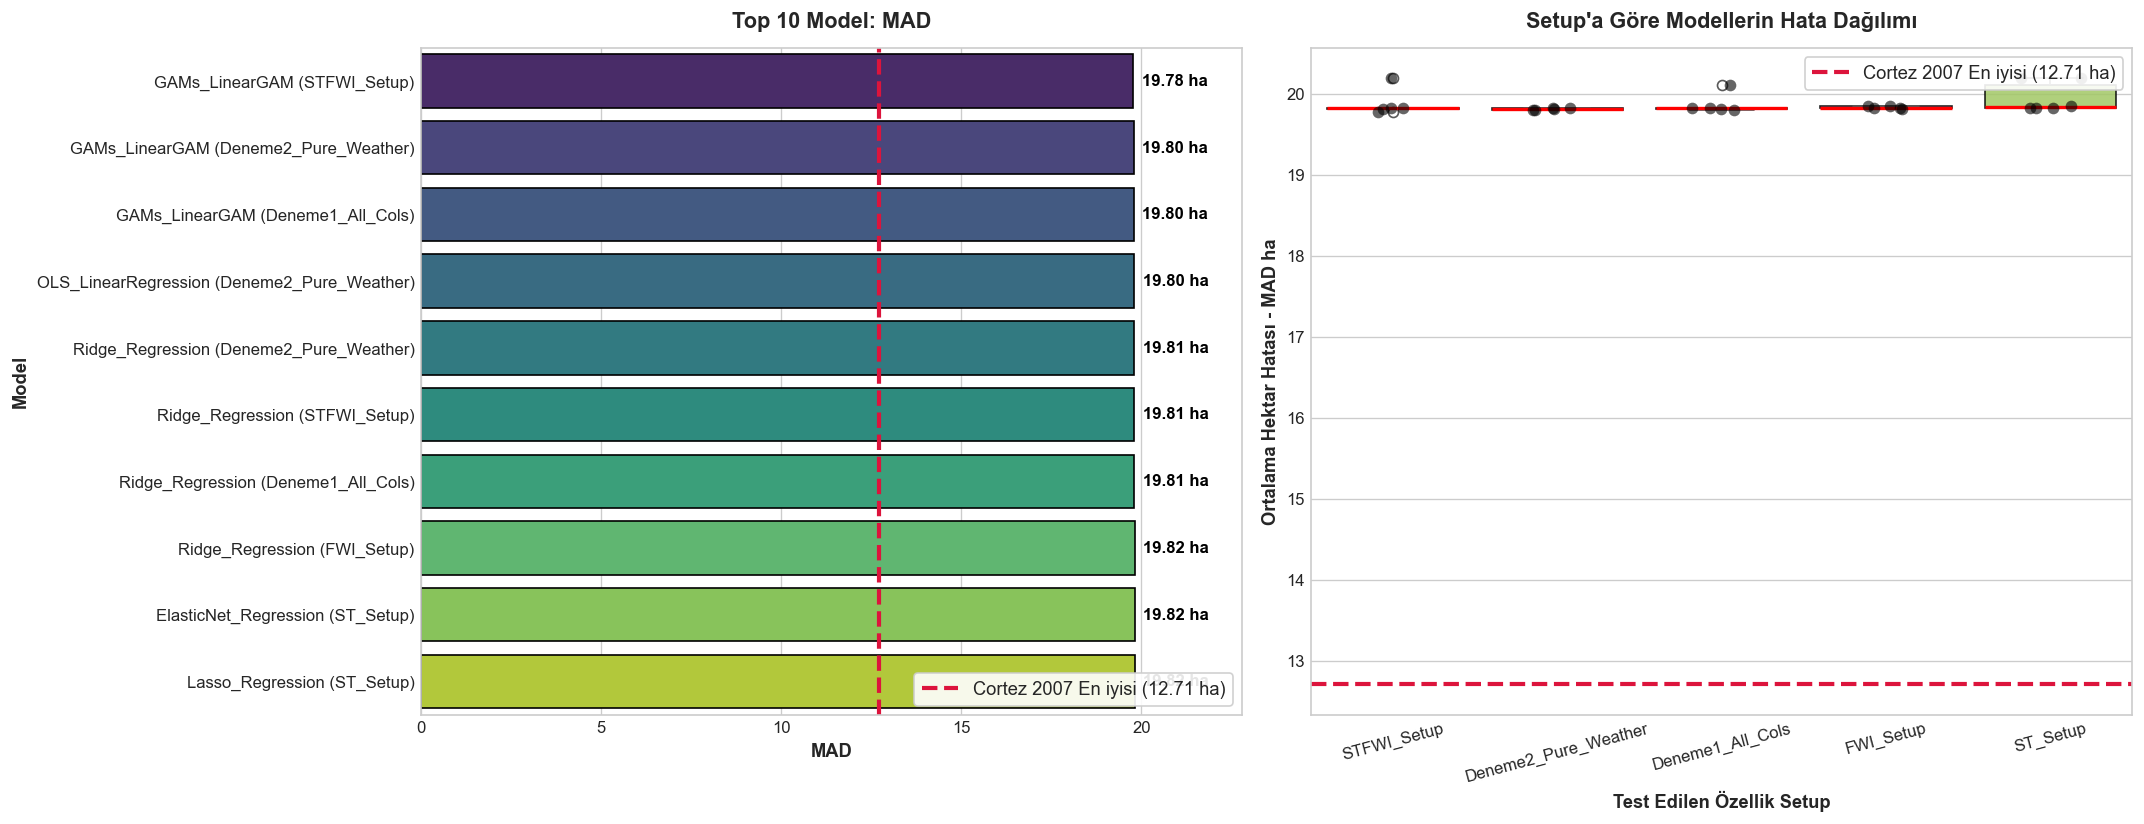

In [17]:
all_runs = mlflow.search_runs(experiment_names=["01_Linear_Models_Benchmarking"])

def extract_setup(row):
    for col in ["params.setup_name", "params.setup", "tags.setup_name"]:
        if col in row and pd.notna(row[col]): return row[col]
    r_name = str(row.get("tags.mlflow.runName", ""))
    for s in ["STFWI_Setup", "FWI_Setup", "ST_Setup", "Deneme2_Pure_Weather", "Deneme1_All_Cols"]:
        if s in r_name: return s
    return "M_Setup"

master_df = pd.DataFrame({
    "Model": all_runs["params.model_name"] if "params.model_name" in all_runs else all_runs["tags.mlflow.runName"].apply(lambda x: str(x).split("_")[0]),
    "Setup": all_runs.apply(extract_setup, axis=1),
    "R2_Score": all_runs.get("metrics.val_r2", np.nan),
    "Log_RMSE": all_runs.get("metrics.val_log_rmse", np.nan),
    "Hectare_RMSE_ha": all_runs.get("metrics.test_ha_rmse", np.nan),
    "Cortez_MAD_ha": all_runs.get("metrics.test_ha_mad", np.nan),
    "Zero_Day_FP_Sum_ha": all_runs.get("metrics.zero_day_fp_sum_ha", np.nan)
})

master_df = master_df.dropna(subset=["Cortez_MAD_ha"]).sort_values(by="Cortez_MAD_ha", ascending=True).reset_index(drop=True)

styled_table = (master_df.head(15).style
    .background_gradient(subset=["Cortez_MAD_ha", "Log_RMSE", "Hectare_RMSE_ha"], cmap="YlGn_r") # Düşük hata yeşil
    .background_gradient(subset=["R2_Score"], cmap="YlGn") # Yüksek R2 yeşil
    .format({
        "R2_Score": "{:.4f}",
        "Log_RMSE": "{:.4f}",
        "Hectare_RMSE_ha": "{:.2f} ha",
        "Cortez_MAD_ha": "{:.4f} ha",
        "Zero_Day_FP_Sum_ha": "{:.2f} ha"
    })
    .set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI', 'font-size': '11pt'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)
display(styled_table)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

top_models_plot = master_df.head(10).copy()
top_models_plot["Model_Setup"] = top_models_plot["Model"] + " (" + top_models_plot["Setup"] + ")"

sns.barplot(
    data=top_models_plot, 
    x="Cortez_MAD_ha", 
    y="Model_Setup", 
    palette="viridis", 
    ax=axes[0],
    edgecolor="black"
)

axes[0].axvline(12.71, color='crimson', linestyle='--', linewidth=2.5, label='Cortez 2007 En iyisi (12.71 ha)')
axes[0].set_title("Top 10 Model: MAD", fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel("MAD", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Model", fontsize=11, fontweight='bold')

for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'{width:.2f} ha',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                fontsize=10, color='black',
                xytext=(5, 0),
                textcoords='offset points',
                fontweight='bold')

axes[0].set_xlim(0, max(top_models_plot["Cortez_MAD_ha"].max() * 1.15, 15))
axes[0].legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)

sns.boxplot(
    data=master_df, 
    x="Setup", 
    y="Cortez_MAD_ha", 
    palette="Set2", 
    ax=axes[1],
    boxprops=dict(alpha=0.85, edgecolor='black'),
    medianprops=dict(color='red', linewidth=2)
)
sns.stripplot(data=master_df, x="Setup", y="Cortez_MAD_ha", color="black", alpha=0.6, jitter=0.2, size=7, ax=axes[1])

axes[1].axhline(12.71, color='crimson', linestyle='--', linewidth=2.5, label='Cortez 2007 En iyisi (12.71 ha)')
axes[1].set_title("Setup'a Göre Modellerin Hata Dağılımı", fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel("Test Edilen Özellik Setup", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Ortalama Hektar Hatası - MAD ha", fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

# `01_Linear_Models.ipynb` DEĞERLENDİRME RAPORU

Montesinho orman yangınları veri seti üzerinde gerçekleştirilen 3 farklı özellik mühendisliği denemesi (`Deneme 1: M_Setup`, `Deneme 2: Pure Weather`, `Deneme 3: ST, FWI, STFWI`) ve 25'ten fazla optimizasyon koşusu sonucunda aşağıdaki temel çıkarımlara ulaşılmıştır:

### 1. En iyi Model ve Kurulum (`GAMs + STFWI_Setup`)
Doğrusal modellerin en iyi performans göstererni, Cortez (2007)'nin en kapsamlı kurulumu olan **`STFWI_Setup` (22 Sütun)** üzerinde çalışan **`GAMs_LinearGAM` (Esnek Genelleştirilmiş Toplamsal Model)** olmuştur.
* **Skorlar:** `Cortez_MAD_ha = 19.7792 ha`, `Log_RMSE = 1.4599`, `R2_Score = 0.0303 (+%3.03)`
* **Gerekçe:** Sıcaklık, rüzgar ve nem gibi fiziksel değişkenlerin orman yangını büyüklüğü üzerindeki etkisi doğrusal değildir (`Non-Linear`). GAMs, sürekli değişkenlere çizdiği 6 bükümlü spline eğrileri (`s(i)`) sayesinde doğrusal denklemleri (`OLS, Ridge, Lasso`) açık ara geride bırakmıştır.

### 2. Gürültü Temizliği (`Deneme 2 Kazanımı`)
Takvim (`month, day`) ve konum (`X, Y`) sütunlarının yaratmış olduğu aşırı seyreklik (`Sparsity`) ve çoklu doğrusallık, Deneme 1'de OLS modelini iflasa (`-0.0472 R²` ve `145.85 ha` sahte alarm) sürüklemiştir. Ancak Deneme 2'de yalnızca **8 Saf Meteoroloji Değişkenine (`Pure Weather`)** geçildiğinde, **OLS modeli `+0.0031 R²` ve `19.8038 ha MAD` skoruna sıçrayarak sahte pozitif hatasını %31 oranında (`45 hektar`) düşürmüştür.** Bu bulgu, gereksiz kategorik dummylerin regresyon modellerindeki yıkıcı etkisini net biçimde kanıtlamaktadır.